In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from palmerpenguins import load_penguins
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

# Chapter 10

Why might we not want to measure prediction success on the training data? Consider the model specification “Find the most similar house in the training data, and predict that price?” If we use this approach to make predictions about the houses in the training data, what will happen?

* If we want to predict the price of a house in the training data, we look for the most similar house, which is… itself! So we predict the price perfectly!


## Train/Test/Split
Try running the above code, and looking at the objects it produces. Answer the following questions:

How many rows are in the datasets X_train and X_test?
* there are 74 rows in X_train and 25 rows in X_test

How many elements are in the series y_train and y_test?
* y_train has 74, and y_test has 25

In [7]:
dat = pd.read_csv("https://www.dropbox.com/scl/fi/yf8t1x0uvrln93dzi6xd8/housing_small.csv?rlkey=uen32y937kqarrjra0v6jaez4&dl=1")
y = dat['SalePrice']
X = dat[['Gr Liv Area', 'Bedroom AbvGr', 'Neighborhood_NAmes', 'Neighborhood_NWAmes']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

print(X_train.count())
print(X_test.count())
print(y_train.count())
print(y_test.count())

Gr Liv Area            74
Bedroom AbvGr          74
Neighborhood_NAmes     74
Neighborhood_NWAmes    74
dtype: int64
Gr Liv Area            25
Bedroom AbvGr          25
Neighborhood_NAmes     25
Neighborhood_NWAmes    25
dtype: int64
74
25
Gr Liv Area            74
Bedroom AbvGr          74
Neighborhood_NAmes     74
Neighborhood_NWAmes    74
dtype: int64
Gr Liv Area            25
Bedroom AbvGr          25
Neighborhood_NAmes     25
Neighborhood_NWAmes    25
dtype: int64
74
25


What would you change to increase the number of rows in X_train?
* to increase the number of rows in X_train, you would need to change the test_size value. A smaller test_size means a larger X_train size. A test size of 0.2 indicates that 20% of the data will be used as test data and the other 80% will be used as training data.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(X_train.count())
print(X_test.count())
print(y_train.count())
print(y_test.count())

Gr Liv Area            79
Bedroom AbvGr          79
Neighborhood_NAmes     79
Neighborhood_NWAmes    79
dtype: int64
Gr Liv Area            20
Bedroom AbvGr          20
Neighborhood_NAmes     20
Neighborhood_NWAmes    20
dtype: int64
79
20
Gr Liv Area            79
Bedroom AbvGr          79
Neighborhood_NAmes     79
Neighborhood_NWAmes    79
dtype: int64
Gr Liv Area            20
Bedroom AbvGr          20
Neighborhood_NAmes     20
Neighborhood_NWAmes    20
dtype: int64
79
20


Run the code again, and re-examine the objects. Do they contain the exact same data as before? Why or why not?
* no, they do not contain the exact same data because a seed was not set. It will partition the same amount, but not include the same values. The train_test_split function shuffles the data before splitting it into training and test sets by default. This means that each time you run the function, the data will be shuffled differently, leading to potentially different splits.


## Model Fitting
Make a plot of the predicted values versus the true values, y_test, for each of the three models. Which of the three models seems best to you?
* Looking at the plots below, it appears that the linear regression model most closely follows the line of best fit, indicating that the predicted values are close to the actual.

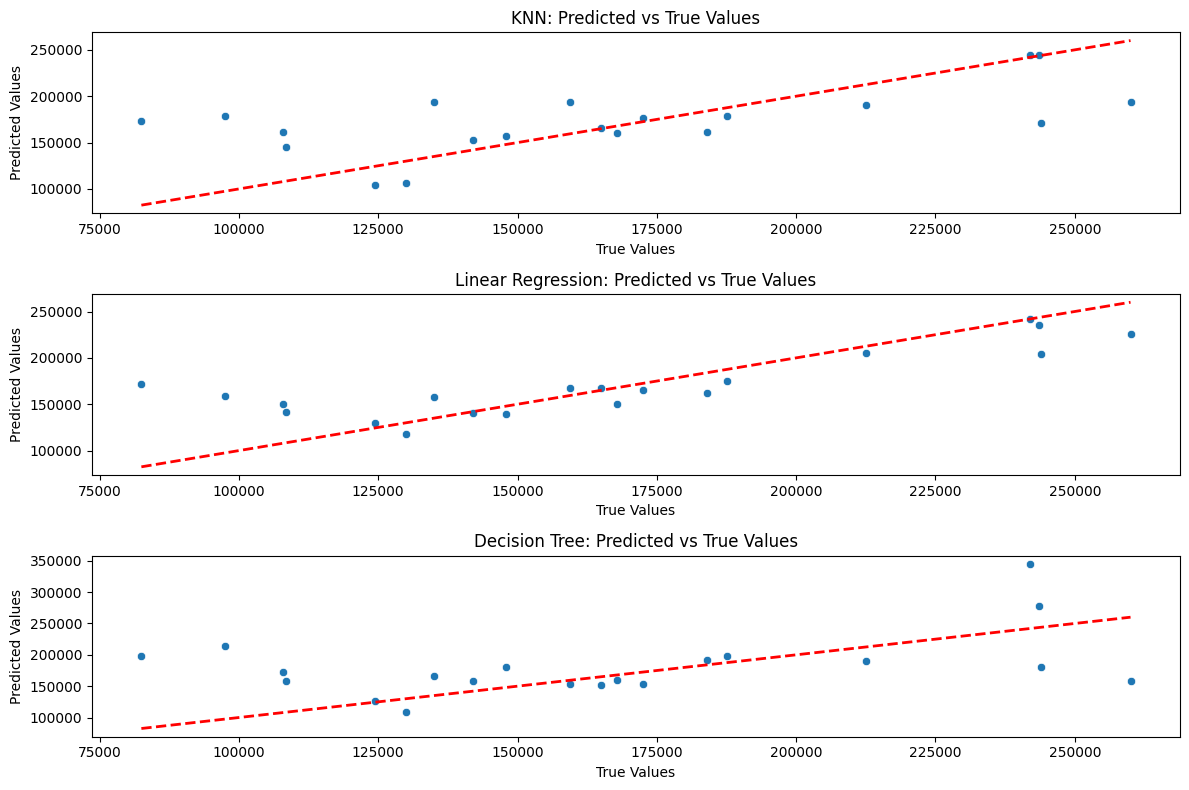

In [20]:
knn = KNeighborsRegressor()
lr = LinearRegression()
dt = DecisionTreeRegressor()

lr_fit = lr.fit(X_train, y_train)
dt_fit = dt.fit(X_train, y_train)
knn_fit = knn.fit(X_train, y_train)

lr_fit.coef_

y_pred_knn = knn_fit.predict(X_test)
y_pred_lr = lr_fit.predict(X_test)
y_pred_dt = dt_fit.predict(X_test)

# Assuming y_test is the true values
plt.figure(figsize=(12, 8))

# KNN
plt.subplot(3, 1, 1)
sns.scatterplot(x=y_test, y=y_pred_knn)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('KNN: Predicted vs True Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')

# Linear Regression
plt.subplot(3, 1, 2)
sns.scatterplot(x=y_test, y=y_pred_lr)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Predicted vs True Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')

# Decision Tree
plt.subplot(3, 1, 3)
sns.scatterplot(x=y_test, y=y_pred_dt)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Decision Tree: Predicted vs True Values')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')

plt.tight_layout()
plt.show()


# Chapter 11

How do we use our data to estimate the values of B0 and B1 in our simple linear regression model?
* we would use our data to find the B0 and B1 values that minimize the sum of squared of residuals.


## Overfitting/Underfitting

Consider the following set of models fit to the Sales dataset from Fig 3.

Which model seems to fit the Sales data best? Why?
* model 3 and 4 seem to fit the data the best, with model 4 slightly overfitting. Model 3 follows the pattern of the data, but it is not overly complex.

What is less good about the other models?
* the other models are under or overfitting

Do you think any of the models in Fig 3. are underfitting the data here? If so, which ones and why?
* yes, degree 1 and 2 are likely underfitting and not capturing the full complexity of the problem

Do you think any of the models in Fig 3. are overfitting the data here? If so, which ones and why?
* yes, degree 5 and 6 are likely overfitting as they follow the curvature of the points too closely, capturing more of the variability and noise in the data, making it harder to generalize.


Which of these models are underfitting? Overfitting? Why? Fig 4
* degree 1 is underfitting and is not taking the complexity of the data into account, as the curvature of the points denotes a nonlinear relationship. Degree 5 is overfitting and is capturing too much variability and noise in the data. 


## Dummies

Apply both the OneHotEncoder and get_dummies functions to the species variable in the Palmer Penguins dataset. Observe the results and discuss the differences, if there are any.
* OneHotEncoder prints the output as binary 1 0 encoded variables and creates separate columns for each column category name
* get_dummies produces boolean true/false variables and adds the specified prefix before each species type: species_Adelie

In [29]:
penguins = load_penguins()

# one hot encoder
enc = OneHotEncoder(sparse_output=False)
encoded_species = enc.fit_transform(penguins[['species']])
encoded_df = pd.DataFrame(encoded_species, columns=enc.categories_[0])
encoded_df

,Adelie,Chinstrap,Gentoo
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0
...,...,...,...
339,0.0,1.0,0.0
340,0.0,1.0,0.0
341,0.0,1.0,0.0
342,0.0,1.0,0.0


In [30]:
# get_dummies version
dummies_df = pd.get_dummies(penguins['species'], prefix='species')
dummies_df

,species_Adelie,species_Chinstrap,species_Gentoo
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False
...,...,...,...
339,False,True,False
340,False,True,False
341,False,True,False
342,False,True,False


## Standardizing

Apply the StandardScaler function to the bill_length_mm variable in the Palmer Penguins dataset. Observe the results. Did you overwrite the original variable or create a new one? If the former, are you able to get back to the original variable if you wanted to?
* yes, you can overwrite it if you wanted, but you can also create a new column that includes the scaled version. if you overwrite it, you can't go back to the original column unless they are stored somewhere

In [35]:
scale = StandardScaler()

penguins["scaled_bill_length"] = scale.fit_transform(penguins[['bill_length_mm']])
print(penguins[['bill_length_mm', 'scaled_bill_length']].head())

   bill_length_mm  scaled_bill_length
0            39.1           -0.884499
1            39.5           -0.811126
2            40.3           -0.664380
3             NaN                 NaN
4            36.7           -1.324737
   bill_length_mm  scaled_bill_length
0            39.1           -0.884499
1            39.5           -0.811126
2            40.3           -0.664380
3             NaN                 NaN
4            36.7           -1.324737


# Chapter 12

Let’s try, once again, to predict bill_depth_mm in the Palmer Penguins dataset. However, you should use all available predictors in the dataset. Train your model on the entire dataset and compute the sum of the squared residuals for your fitted model.

Is your multiple regression model good?!

* the lower the SSR, the better, however it is meaningless when there is only one model. It is best for comparing predictability between models.
* SSR represents the total squared difference between the predicted and actual values, so a lower SSR indicates smaller errors between predictions and actual observations.

In [52]:
penguins = penguins.dropna()

X = penguins.drop("bill_depth_mm", axis = 1)
y = penguins["bill_depth_mm"]

X = pd.get_dummies(X, drop_first=True).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

residuals = y_test - y_pred
ssr = (residuals ** 2).sum()
print(ssr)


30.420646887076
30.420646887076


Compute the R-squared value for the your full model from above and comment on its value concerning the model fit.
* An r^2 value of 0.88 indicates that 88% of the variation in predicted bill depth is explaine by the line of regression

In [47]:
r2 = r2_score(y_test, y_pred)
r2

0.8826932686822602

## Metrics

There is a large number of metrics we can use to evaluate models of different types. Identify at least two different metrics we could use to evaluate our bill_depth_mm model:

* r2
* mse

Split the penguin dataset into training and testing subsets. Fit your model to the training data and compute the value of your two metrics on the test data.

In [53]:
mse = mean_squared_error(y_test, y_pred)
mse

np.float64(0.4540395057772537)

In the graph above, which model is underfit? Which model is overfit? Does this make sense in the right graph as well? How does the right graph help us assess under/overfit when the model isn’t visualizable? (Fig 1 Ch. 12)

* the yellow line appears to be underfitting as it is a simple linear model and is not capturing the potential complexity of nonlinear relationships
* the green line is overfitting because it is overly complex and is capture all variability and noise in the data, making it not generalizable
* the blue line appears to be capturing the curvature of the data, but is not overly complex so it can be generalized to other datasets

* this matches the graph on the right because we see the blue points with the lowest mse values as well as the closest values from training to test set.
* the yellow points have values that have close training/test set mses, however they are higher than the blue points. this indicates that they are underfitting the model due to the higher mse.
* the final points (green) has a big difference between the training and test data. This indicates that it is overfitting because the data that it is trained on isn't generalizable to the rest of the dataset. Even though it has the lowest MSE, we wouldn't want to use this model.

# Chapter 13

What went wrong here? We fit the test data and predicted r2 value, but it turned out to be -2 million! and predictions seem to be incredibly high!

* the data needs to be standardized! since the features are all different scales, they need to be standardized to assume consistency


Now a new house has come along, and you need to predict it. That house has a living area of 889 square feet, and 6 rooms.

new_house = pd.DataFrame(data = {"Gr Liv Area": [889], "TotRms AbvGrd": [6]})

When we do this:
new_house_s = (new_house - new_house.mean())/new_house.std()
new_house_s

our data becomes NaN! How do we fix it?

* the new data needs to go through the same preprocessing steps as the old data! so, instead of using new_house mean and sd, we would use the standard deviation from the X_train to calculate r2 and mse:
X_test_s = (X_test - X_train.mean())/X_train.std()
y_preds = lr_fitted.predict(X_test_s)

r2_score(y_test, y_preds)


## Column Transformers

What does the remainder = "drop" part of the ColumnTransformer() function do? Why might that be useful?

Hint: What happens when you try to fit this pipeline on X_train?

* remainder = "drop", drops all other variables that aren't specified inside of the column transformer. this might be helpful if you only want to transform and include certain variables in the model without filtering the dataset

* when you fit the pipeline on X_train, it keeps only the specified columns below



In [60]:
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
  [
    ("dummify", OneHotEncoder(sparse_output = False), ["Bldg Type"]),
    ("standardize", StandardScaler(), ["Gr Liv Area", "TotRms AbvGrd"])
  ],
  remainder = "drop"
)

lr_pipeline = Pipeline(
  [("preprocessing", ct),
  ("linear_regression", LinearRegression())]
)

ames = pd.read_csv("/Users/chloefeehan/Desktop/python/GSB544/In_Class/Week_7/AmesHousing.csv")
X = ames.drop("SalePrice", axis = 1)
y = ames["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(X, y)

lr_fitted = lr_pipeline.fit(X_train, y_train)


Recall that the model fitting step is when coefficients are computed for the linear regression.

How many different model fitting steps occurred when gscv.fit(X, y) was run?

* the GridSearchCV() function performs a grid search over however many degrees (params) specified as well as the number of folds specified. so if it has a 5-fold cross validation for degrees 1-10, it would be 10*5, therefore 50 times it was fit.

# Chapter 14

ct = ColumnTransformer(
  [
    ("dummify", 
    OneHotEncoder(sparse_output = False, handle_unknown='ignore'),
    make_column_selector(dtype_include=object)),
    ("standardize", 
    StandardScaler(), 
    make_column_selector(dtype_include=np.number))
  ],
  remainder = "passthrough"
)

Notice in the Column Transformer, we added the argument handle_unknown='ignore'What did this accomplish?

* handle_unknown handles categories that weren't seen in the training set. 
the encoder will ignore the new category and represent it as a row of all zeros (essentially treating it as a missing or unknown value)

Notice in the OneHotEncoder, we used make_column_selector(dtype_include=object) instead of supplying column names. What did this accomplish?
* this selected columns that were of type object (categorical)

# Chapter 15

## kNN

As the value of K increases does our k-Nearest Neighbors model become more or less complex? Are we more likely to be underfitting or overfitting our data, with a large value of K?
* we would expect the model to become less complex as K increases, therefore we would run the risk of underfitting with a large K because it might underfit the intricacies of the data
* the model becomes less complex because it makes predictions based on more neighbors, reducing the impact of individual data points
* As K increases, the model becomes less sensitive to individual data points and averages over more neighbors, making the decision boundary smoother and less likely to overfit


In the visualization above, which model has the smaller value of K? How can you tell? What does this suggest about training and test error for a kNN model?
* the model on the left has a larger K value because it is less complex and demonstrates a smoother decision boundary
* the model on the right has a smaller K value since it is more complex. this can lead to overfitting because the model becomes highly sensitive to the noise in the training data

## Decision Trees

How would you read the decision tree above? What do the values at the bottom represent and how would you make a prediction for a new baseball player?

* the values at the bottom represent the final predicted label based on the condition specified above
* you can predict a new baseball player by following the conditions


If splits are created to reduce the error the most at each step, then what can be said about variables at split at the top of the tree versus lower in the tree?
* the variables that are higher on the tree are based on variables that have the most impact on reducing the error. higher predictive power at the top

* as you move down, the splits become less impactful since they have already been split into homogenous groups. these refine the prediction, but not necessarily reduce error


What would happen if we gave the model our whole training dataset and let it grow as much as it could?
* it would lead to overfitting and an overly complex model
* it wouldn't necessarily take into account the typical variability we would see in the real world and wouldn't be generalizable

A decision tree grown to the point of having a terminal node for each observation in our training dataset would be considered overly complex. What would the training error of such a model be? What would you expect of the test error?
* the training error would be 0 because it would perfectly fit the data and the test error would be high due to overfitting of the training model, therefore making it not generalizable to the test set/unseen data

What would the fitted decision tree look like if alpha = 0? What about alpha = 1,000,000,000?
* the alpha parameter relates to pruning of the tree. the higher the alpha, the more pruning takes place
* an alpha of 0 would mean that there would be no pruning and the tree would split until terminal nodes. This would lead to overfitting of the model
* an alpha of 1,000,000,000 would be very simple with not very many splits. this would be underfitting

# Chapter 16

## Logistic Regression Classification
What type of quantity would we want to minimize in a penalized logistic regression situation?
* minimize the penalized loss function which contains both the error and the penalty on the complexity
* the penalty added to the loss function is to help prevent overfitting by discouraging overly complex models
    * penalty = l1 drives some coefficients to exactly zero (as seen in LASSO)
    * penalty = l2 regularization shrinks coefs towards zero


Open the Palmer Penguins dataset and create the following gentoo variable:

A value of 1 if the species variable is Gentoo
A value of 0 otherwise

Use the other variables in the dataset and a logistic regression model to classify penguins as either “Gentoo” or “Not”. What is your training accuracy?

In [80]:
penguins = load_penguins()
penguins = penguins.dropna()

penguins['Gentoo'] = (penguins['species'] == 'Gentoo').astype(int)

X = penguins.drop(['species', 'Gentoo'], axis=1)
y = penguins['Gentoo']

categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),  # Scale numeric features
        ('cat', OneHotEncoder(drop='first'), categorical_cols)  # One-hot encode categorical features
    ])

lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('logreg', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

lr_pipeline.fit(X_train, y_train)

y_pred = lr_pipeline.predict(X_test)
training_accuracy = accuracy_score(y_test, y_pred)

print(f"Training Accuracy: {training_accuracy:.4f}")


Training Accuracy: 1.0000
Training Accuracy: 1.0000


## kNN Classification
In the graph above, has either model overfit the data? Underfit? How can you tell?
* K = 1 appears to be overfitting the data because it's capturing the curvature of the points almost exactly
* K = 100 appears to be underfitting the data because it's not taking into account non-linear relationships, which this appears to have due to the curving model


What would be your general recommendations for values of K to use when using kNN for classification?
* i would recommend using a K of 3-10 and see which one produces the best metrics

## Decision Tree Classification

In the graph above, we see the same type of variable splitting from the top to the bottom. However, at the bottom of the tree we have “Yes” and “No” values instead of average numeric values. What do these values represent? How are they arrived at?

* these values represent the final class labels of the categories
* Once the tree reaches the terminal nodes (or leaf nodes), it assigns the most frequent class from the training data points that are in that leaf.
* the labels are based on proportions

How are we estimating and using our probabilities of interest using a decision tree?
* the probabilities of interest are estimated based on the proportions of each class in the leaf nodes
* Class Probabilities: At each leaf, the class probabilities are the proportion of samples belonging to each class in that nodes


Open the Palmer Penguins dataset.

Use the other variables in the dataset and a decision tree model to classify the penguins using the species as the target variables.

What is your training accuracy?


In [83]:
penguins = load_penguins()
penguins = penguins.dropna()

X = penguins.drop('species', axis=1) 
y = penguins['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(), ['island', 'sex']),  # Apply OneHotEncoder to categorical columns
        ('num', 'passthrough', ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'])  # Keep numerical features unchanged
    ])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=1))  # Decision tree model
])

pipeline.fit(X_train, y_train)

y_train_pred = pipeline.predict(X_test)

train_accuracy = accuracy_score(y_test, y_train_pred)
print(f'Training Accuracy: {train_accuracy}')


Training Accuracy: 0.9104477611940298
Training Accuracy: 0.9104477611940298


For the species classification model (kNN or decision tree) of the Palmer Penguins data, construct a confusion matrix of your results on the training data.

What kinds of errors are most prevalent?
* majority of predictions are correct
* Adelie species (row 1): 2 instances of Adelie were misclassified as Chinstrap (column 2), and 3 instances of Chinstrap were misclassified as Adelie.
* Chinstrap species (row 2): There were 3 Adelie misclassified as Chinstrap and 1 Chinstrap misclassified as Adelie.
* Gentoo species (row 3): There are no errors for Gentoo; the model correctly identified all instances of this species.


In [85]:
cm = confusion_matrix(y_test, y_train_pred)
cm

array([[26,  2,  0],
       [ 3, 10,  0],
       [ 1,  0, 25]])

## ROC/AUC

With respect to Fig 4. What does “Random classifier” correspond to? How would this classifier work?
* this random classifier corresponds to a model that makes predictions at random
* For binary classification, this classifier would predict one of the two classes randomly with a 50% chance
* the random classifier would have an AUC of approximately 0.5, indicating it is no better than random guessing

How are these curves being constructed? That is, what does each point on these curves represent?
* constructed to evaluate the performance of a binary classification model
* each point on the ROC corresponds to a cutoff value that the model uses to classify which category it would go into
    * Increasing the threshold generally results in fewer positive predictions --> higher FPR and lower TPR
    * Decreasing the threshold increases the number of positive predictions --> TPR increases and FPR increases
* Top-left corner (0, 1): This represents the ideal scenario, where the model achieves 100% True Positives and 0% False Positives.

What is the range of values for the AUC of a classifier? What values are more desirable?
* AUC is 0 to 1 where 1 is perfectly classified, 0.5 is no better than random guess, and 0 is worse than random guessing

# Chapter 18

Your four OvR Logistic Regressions produced four probabilities for each observation: prob of cp_is_0, prob of cp_is_1, etc.

Is it guaranteed that these four probabilities add up to 1? Why or why not?
* no, these would not add up to 1 because each classifier predicts independently
* the classifiers don't take into account the other, they are independent


Why do you think we reported ROC-AUC instead of F1 Score this time?
* ROC-AUC performs better in multi-class scenarios, doesn't depend on fixed threshold like f1
* F1 is typically used for binary classification


Your three OvO Logistic Regressions produced four probabilities for each observation: prob of 0 compared to 1, prob of 0 compared to 2, and prob of 0 compared to 3. Is it guaranteed that these four probabilities add up to 1? Why or why not?
* No, each model is trained to distinguish between two specific classes, but they don't consider the probabilities for the remaining classes in the system

If we had done all the OvO pairs, how many regressions would we have fit? *******

How would you use the results of all the OvO pairs to arrive at one final class prediction?



If you randomly guess categories in a two-class setting by flipping a coin, how often do you expect to be right?
* 50%, assuming equal opportunity

If you randomly guess categories in a six-class setting by rolling a die, how often do you expect to be right?
* 16.7%

What does this tell you about what you should consider a “good” accuracy for a model to achieve in multiclass settings?
* for multiclass, if the model's accuracy is higher than the random guessing accuracy, then the model is performing well

